<a href="https://colab.research.google.com/github/23064088/DataMiningGroup18/blob/data_generation_latest%2Bsentiment_analysis/Data_Generation_Latest_With_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
from transformers import pipeline

In [2]:
file_path = "/content/sample_data/Financial_Data_Latest.csv"
df = pd.read_csv(file_path)

print("✅ Dataset loaded")
df.head()

✅ Dataset loaded


,id_num,age,monthly_income,credit_score,loan_amount,interest_rate,debt_to_income_ratio,late_payment_count_12m,financial_confidence,bank_type,risk_keywords_present,customer_statement,loan_default,risk_flag
0,bdd640fb-0667-4ad1-9c80-317fa3b1799d,59,3360,578,43158,19.639879,12.844643,0,Medium,Traditional,0,I am writing to report financial difficulties ...,1,2
1,23b8c1e9-3924-46de-beb1-3b9046685257,42,3269,648,7433,8.636499,2.273784,0,Low,Traditional,0,I want to invest my savings in the very moment...,0,0
2,bd9c66b3-ad3c-4d6d-9a3d-1fa7bc8960a9,62,4547,718,7747,12.327237,1.703761,0,Medium,Digital,0,I want to invest my savings in the next year. ...,1,0
3,972a8469-1641-4f82-8b9d-2434e465e150,41,7893,667,15627,23.844035,1.979856,1,Medium,Traditional,0,I want to invest my savings in the next year. ...,0,0
4,17fc695a-07a0-4a6e-8822-e8f36c031199,64,3275,573,49974,8.467293,15.259237,1,Low,Traditional,0,I am writing to report financial difficulties ...,1,2


In [3]:
print("⏳ Loading FinBERT model...")
classifier = pipeline("sentiment-analysis", model="ProsusAI/finbert")
print("✅ FinBERT loaded")

⏳ Loading FinBERT model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/758 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/438M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/252 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/438M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cuda:0


✅ FinBERT loaded


In [4]:
def get_sentiment_score(text):
    # Make sure the input is a string and limit length for the model
    text = str(text)[:512]

    try:
        # Run FinBERT sentiment analysis on the text
        result = classifier(text)[0]

        # If sentiment is negative, return the confidence score (higher = more negative)
        if result['label'] == 'negative':
            return result['score']

        # If sentiment is positive, invert the score (lower risk signal)
        elif result['label'] == 'positive':
            return 1 - result['score']

        # Neutral sentiment gets a middle value
        else:
            return 0.5

    # If anything goes wrong, return neutral score
    except:
        return 0.5


In [5]:
# Apply sentiment scoring to each customer statement
df['Sentiment_Score'] = df['customer_statement'].apply(get_sentiment_score)

# Quick check
df[['customer_statement', 'Sentiment_Score']].head()


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,customer_statement,Sentiment_Score
0,I am writing to report financial difficulties ...,0.500000
1,I want to invest my savings in the very moment...,0.500000
2,I want to invest my savings in the next year. ...,0.500000
3,I want to invest my savings in the next year. ...,0.500000
4,I am writing to report financial difficulties ...,0.313378


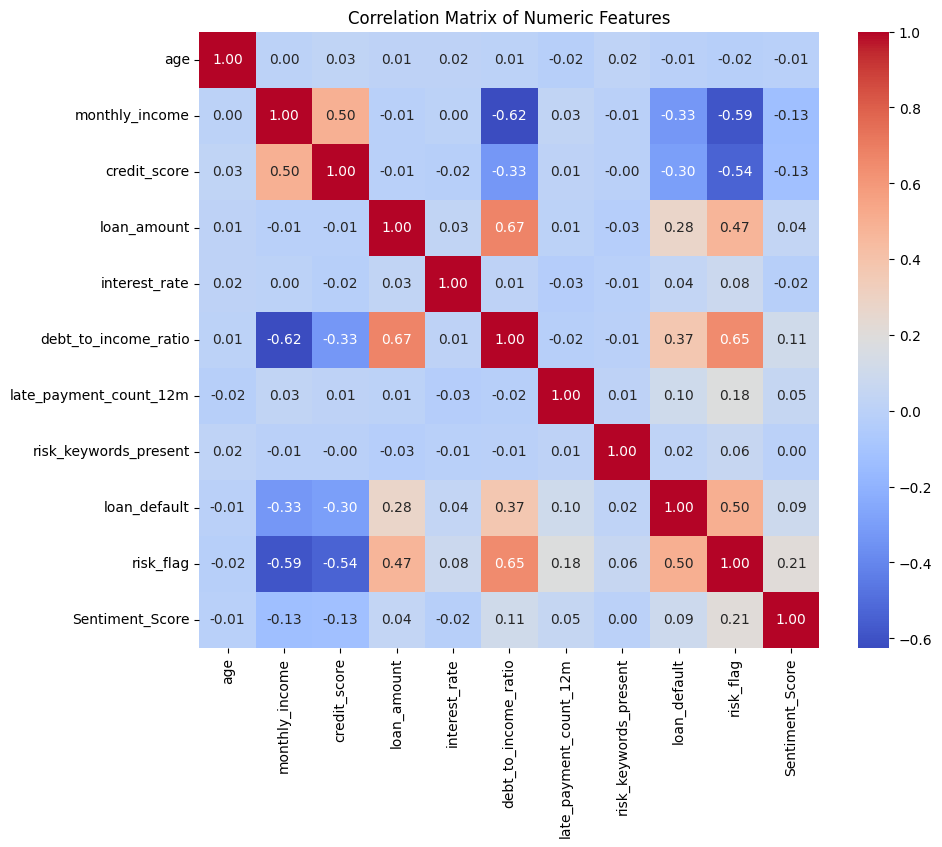


Correlation values for Sentiment_Score:
Sentiment_Score           1.000000
risk_flag                 0.209141
debt_to_income_ratio      0.107996
loan_default              0.087405
late_payment_count_12m    0.054434
loan_amount               0.036520
risk_keywords_present     0.002929
age                      -0.009748
interest_rate            -0.016626
credit_score             -0.127973
monthly_income           -0.132214
Name: Sentiment_Score, dtype: float64


In [6]:
# Check correlation

import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns
numeric_cols = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numeric_cols.corr()

# Display heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm')
plt.title("Correlation Matrix of Numeric Features")
plt.show()

# Optional: quick numeric check
print("\nCorrelation values for Sentiment_Score:")
print(corr_matrix['Sentiment_Score'].sort_values(ascending=False))

In [7]:
# Save the dataset with sentiment column added
output_path = "/content/sample_data/Financial_Data_New_With_Sentiment.csv"
df.to_csv(output_path, index=False)

print(f"✅ Sentiment analysis complete. New dataset saved as: {output_path}")

✅ Sentiment analysis complete. New dataset saved as: /content/sample_data/Financial_Data_New_With_Sentiment.csv
